In [1]:
import gc
# import torch

gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

import os
os.listdir(); os.chdir("/aiau010_scratch/azm0269/clover/")

from clover.utils.utils import notebook_line_magic
notebook_line_magic()

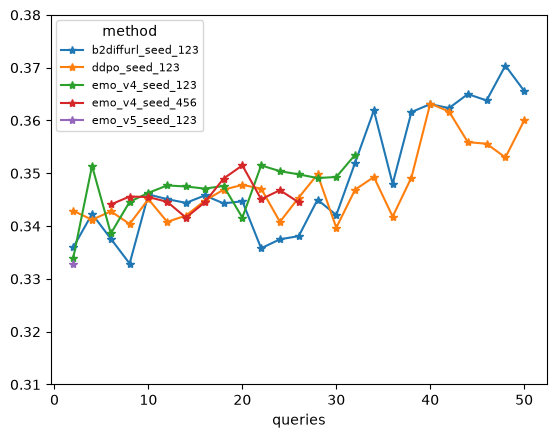

In [93]:
import json
from pathlib import Path
import pandas as pd
import numpy as np

current_baselines = [
    "emo", "emo_v2", "emo_v3", "emo_v4", "emo_v5",
    "emo_v3_old", "ddpo", "b2diffurl", 
    "emo_v4_reward_2_kl_0.01_diversity_0.25",
    "emo_v4_reward_2_kl_0.01_diversity_0.5",
    "emo_v4_reward_10_kl_0.05_diversity_0.25" 
] 
baselines = [
    "emo", "emo_v2", "emo_v3",  "emo_v4", "emo_v5", "emo_v3_old",
    "ddpo", "b2diffurl", "dpok", 
    "emo_v4_reward_2_kl_0.01_diversity_0.25",
    "emo_v4_reward_2_kl_0.01_diversity_0.5",
    "emo_v4_reward_10_kl_0.05_diversity_0.25" 
]
eval_path = Path("outputs/")
training_data_eval_file = "training_metrics.json"
evaluation_data_eval_file = "eval_metrics.json"

def get_training_metrics_df(file_path):
    if file_path.exists():
        with open(file_path, "r") as f:
            list_of_metrics = json.load(f)
    else:
        # print(f"File {file_path} does not exist. Skipping.")
        return pd.DataFrame()  # Return an empty DataFrame if the file doesn't exist
    all_metric_entries = []
    for entry in list_of_metrics:
        all_metric_entries.append(entry['metrics'])
    df = pd.DataFrame(all_metric_entries)
    return df

def get_eval_metrics_df(file_path):
    if file_path.exists():
        with open(file_path, "r") as f:
            list_of_metrics = json.load(f)
    else:
        # print(f"File {file_path} does not exist. Skipping.")
        return pd.DataFrame()  # Return an empty DataFrame if the file doesn't exist
    
    scores = ['bert_reward', 'clip_reward']
    eval_summary = list()
    for entry in list_of_metrics:
        for score in scores:
            eval_summary.append({
                "value": round(np.array(entry[score]).mean(), 4),
                "score": score,
                "epoch": entry['epoch']
            })
    eval_df = pd.DataFrame(eval_summary)
    return eval_df
    
def get_metrics(seeds=[123, 456]):
    training_eval_df = pd.DataFrame()
    eval_df = pd.DataFrame()
    for seed in seeds:
        for baseline in baselines:
            baseline_path = eval_path / baseline
            training_data_eval_file_path = baseline_path / "training_evals" / training_data_eval_file if baseline not in current_baselines else baseline_path / f"seed_{seed}/training_evals" / training_data_eval_file
            eval_data_file_path = baseline_path / "evals" / evaluation_data_eval_file if baseline not in current_baselines else baseline_path / f"seed_{seed}/evals" / evaluation_data_eval_file

            
            df = get_training_metrics_df(training_data_eval_file_path)
            df["method"] = baseline+f"_seed_{seed}"
            training_eval_df = pd.concat([training_eval_df, df], ignore_index=True)

            df = get_eval_metrics_df(eval_data_file_path)
            df["method"] = baseline+f"_seed_{seed}"
            eval_df = pd.concat([eval_df, df], ignore_index=True)
    return training_eval_df, eval_df


training_eval_df, eval_df = get_metrics(seeds=[123, 456])

import matplotlib.pyplot as plt

temp_eval_df = eval_df[eval_df['score'] == 'clip_reward']

baselines = [
    "b2diffurl_seed_123", "ddpo_seed_123",
    "emo_v4_seed_123", "emo_v4_seed_456", "emo_v5_seed_123"
]
temp_eval_df = temp_eval_df[temp_eval_df['method'].isin(list(set(baselines)-set(["dpok_old"])))]
eval_summary = temp_eval_df.pivot_table(
    index=['method', 'score'],
    columns='epoch',
    values='value',
)
# eval_summary.T.iloc[:, 0].plot()
# plt.title("Bert Reward")
# plt.show()
# eval_summary.T.iloc[:, 1].plot()
# plt.title("Clip Reward")
# plt.show()
summary_baselines = [
    "b2diffurl_seed_123", "ddpo_seed_123", #"emo_v2",
    "emo_v4_seed_123", "emo_v4_seed_456", "emo_v5_seed_123" #"emo_v4_reward_2_kl_0.01_diversity_0.25",
    #"emo_v4_reward_2_kl_0.01_diversity_0.5",
    # "emo_v4_reward_10_kl_0.05_diversity_0.25" 
]
transposed_eval_summary = eval_summary.T
transposed_eval_summary = transposed_eval_summary.reset_index().droplevel(level=1, axis=1)
# transposed_eval_summary[transposed_eval_summary.index.isin([2]+list(range(0, 50, 5)))].rolling(window=2).mean().round(3).plot(marker='o')
transposed_eval_summary['queries'] = transposed_eval_summary['epoch'].astype(int)#*256
transposed_eval_summary.pivot_table(
    index='queries',
    values=summary_baselines,
).round(6)\
    .rolling(window=1).mean().iloc[:].plot(
    marker='*', 
    ylim=(0.31, 0.38),
    legend=True) #.iloc[lambda x: np.arange(len(x)) % 5 < 3]
plt.rc('legend', fontsize=8, loc='upper left')

<Axes: xlabel='epoch'>

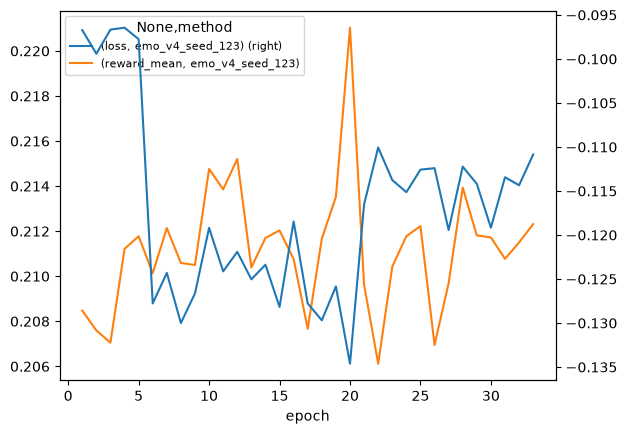

In [90]:
# cols = ['advantage_mean', 'approx_kl', 'current_reward_mean', 'current_reward_std', 'epoch', 'loss', 'parameter_update_norm_mean',
#     'raw_reward_mean', 'raw_reward_std', 'replay_reward_mean',
#     'replay_reward_std', 'reward_mean', 'reward_std', 'selected_samples', 'skipped_updates','method']
# training_eval_df = training_eval_df[cols]
# emo_v4_reward_2_kl_0.01_diversity_0.25
import numpy as np
method = "emo_v4_seed_123"
_training_eval_df = training_eval_df[training_eval_df['method'].isin([method])]
# for col in _training_eval_df.columns:
#         try:
#                 corrcoef = np.corrcoef(_training_eval_df[col], _training_eval_df['reward_mean'])[0,1]
#         except Exception as e:
#                 pass
#         if type(corrcoef) is not np.isnan(corrcoef):
#                 print(f"Correlation for column: {col}|{corrcoef}")
temp_training_eval_df = _training_eval_df[_training_eval_df['method'].isin(list(set(baselines)-set(["dpok_old"])))]
# temp_training_eval_df['loss'] = -1*temp_training_eval_df['loss']
temp_training_eval_df.pivot_table(
        index='epoch',
        columns='method',
        values=['loss', 'reward_mean']
).round(6).iloc[::].rolling(window=1).mean().plot(kind='line', secondary_y=[('loss', method)])
    

In [69]:
# # Convert the logged EMO objectives to minimized loss terms.
# loss_df = _training_eval_df.assign(
#     reward_loss=-_training_eval_df['policy_loss'],
#     entropy_loss=-_training_eval_df['entropy'],
# ).groupby('epoch').mean(numeric_only=True)

# for left, right in [('current_reward_mean', 'reward_loss'), ('loss', 'entropy_loss')]:
#     ax = loss_df[[left, right]].plot(
#         figsize=(6, 3), secondary_y=[right], title=method, grid=False,
#     )
#     ax.set_ylabel(left)
#     ax.right_ax.set_ylabel(right)
#     plt.tight_layout()
#     plt.show()


<Axes: xlabel='epoch'>

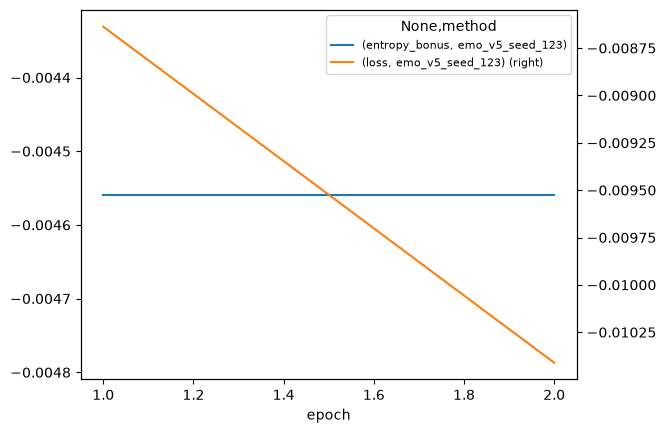

In [89]:
temp_training_eval_df['entropy_bonus'] = -1*temp_training_eval_df['entropy_bonus']
temp_training_eval_df.pivot_table(
    index='epoch',
    columns='method',
    values=['loss', 'entropy_bonus']
).round(6).rolling(window=1).mean().plot(kind='line', secondary_y=[('loss', method)])

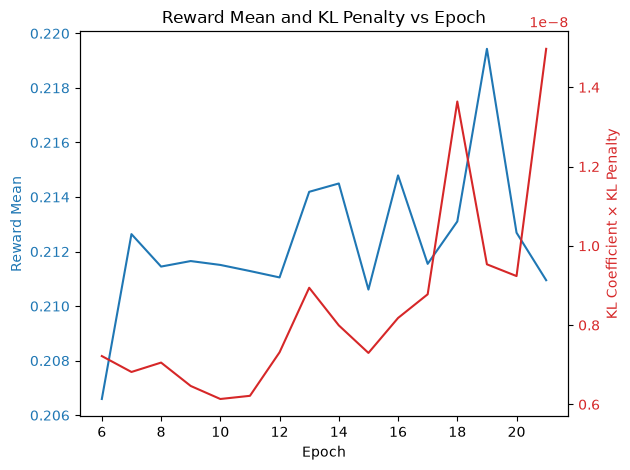

In [71]:
fig, ax1 = plt.subplots()

# Left y-axis
ax1.plot(
    temp_training_eval_df['epoch'],
    temp_training_eval_df['reward_mean'],
    color='tab:blue',
    label='Reward Mean'
)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Reward Mean', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis
ax2 = ax1.twinx()
ax2.plot(
    temp_training_eval_df['epoch'],
    temp_training_eval_df['kl_coefficient'] * temp_training_eval_df['kl_penalty'],
    color='tab:red',
    label='KL Coefficient × KL Penalty'
)
ax2.set_ylabel('KL Coefficient × KL Penalty', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Reward Mean and KL Penalty vs Epoch')
fig.tight_layout()
plt.show()

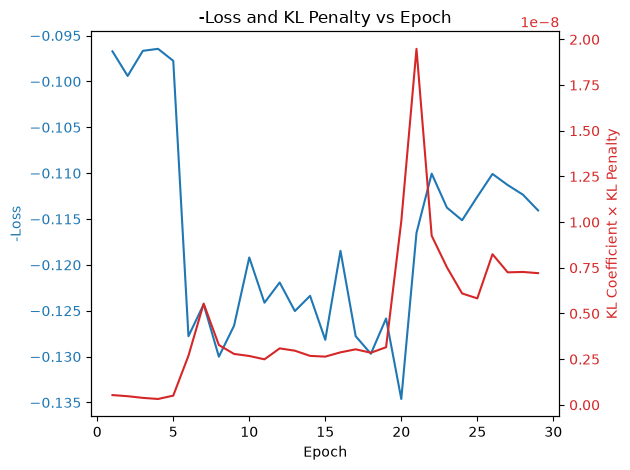

In [66]:
fig, ax1 = plt.subplots()
# Left y-axis
ax1.plot(
    temp_training_eval_df['epoch'],
    temp_training_eval_df['loss'],
    color='tab:blue',
    label='-Loss'
)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('-Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis
ax2 = ax1.twinx()
ax2.plot(
    temp_training_eval_df['epoch'],
    temp_training_eval_df['kl_coefficient'] * temp_training_eval_df['kl_penalty'],
    color='tab:red',
    label='KL Coefficient × KL Penalty'
)
ax2.set_ylabel('KL Coefficient × KL Penalty', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('-Loss and KL Penalty vs Epoch')
fig.tight_layout()
plt.show()

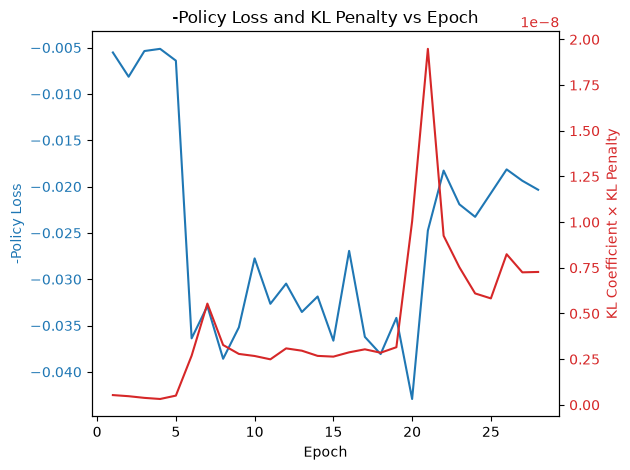

In [56]:
fig, ax1 = plt.subplots()
# Left y-axis
ax1.plot(
    temp_training_eval_df['epoch'],
    -temp_training_eval_df['policy_loss'],
    color='tab:blue',
    label='-Policy Loss'
)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('-Policy Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis
ax2 = ax1.twinx()
ax2.plot(
    temp_training_eval_df['epoch'],
    temp_training_eval_df['kl_coefficient'] * temp_training_eval_df['kl_penalty'],
    color='tab:red',
    label='KL Coefficient × KL Penalty'
)
ax2.set_ylabel('KL Coefficient × KL Penalty', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('-Policy Loss and KL Penalty vs Epoch')
fig.tight_layout()
plt.show()

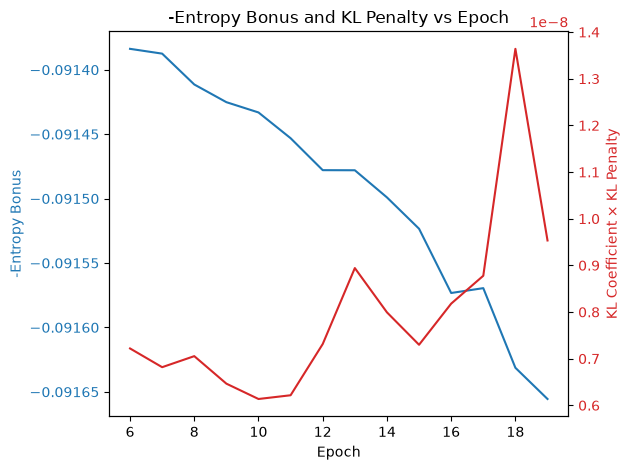

In [40]:
fig, ax1 = plt.subplots()
# Left y-axis
ax1.plot(
    temp_training_eval_df['epoch'],
    -temp_training_eval_df['entropy_bonus'],
    color='tab:blue',
    label='-Entropy Bonus'
)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('-Entropy Bonus', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis
ax2 = ax1.twinx()
ax2.plot(
    temp_training_eval_df['epoch'],
    temp_training_eval_df['kl_coefficient'] * temp_training_eval_df['kl_penalty'],
    color='tab:red',
    label='KL Coefficient × KL Penalty'
)
ax2.set_ylabel('KL Coefficient × KL Penalty', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('-Entropy Bonus and KL Penalty vs Epoch')
fig.tight_layout()
plt.show()